# Using MAITE's Object Detection Protocol with `xaitk-saliency`

This is a simple notebook demonstrating how detectors based on MAITE's object detection protocol can interface with `xaitk-saliency`.

## Table Of Contents
* [Environment Setup](#environment-setup)
* [Example Image](#example-image)
* [Instantiate Protocol-Based Detector](#instantiate-protocol-based-detector)
* [Transform Protocol-Based Detector](#transform-protocol-based-detector)
* [Use the Detector as "Normal"](#use-detector-as-normal)
    * [Get Detections](#get-detections)
    * [Generate Saliency Maps](#generate-saliency-maps)
        * [Prepare Inputs](#prepare-inputs)
        * [Saliency Generation](#saliency-generation)
        * [Display Saliency Maps](#display-saliency-maps)
    

To run this notebook in Colab, use the link below:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kitware/xaitk-saliency/docs/interoperability/maite/examples/maite-object-detector-protocol.ipynb)

## Environment Setup <a name="environment-setup"></a>

**Note for Colab users**: After setting up the environment, you may need to "Restart Runtime" in order to resolve package version conflicts (see the [README](https://github.com/Kitware/xaitk-saliency/blob/main/docs/examples/README.md#run-the-notebooks-from-colab) for more info).

In [ ]:
import sys  # noqa:F401

!{sys.executable} -m pip install -qU pip
print("Installing xaitk-saliency...")
!{sys.executable} -m pip install -q xaitk-saliency
print("Installing headless OpenCV...")
!{sys.executable} -m pip uninstall -qy opencv-python opencv-python-headless  # make sure they're both gone.
!{sys.executable} -m pip install -q opencv-python-headless
print("Installing Hugging Face datasets...")
!{sys.executable} -m pip install -q datasets
print("Installing Hugging Face transformers...")
!{sys.executable} -m pip install -q transformers
print("Installing timm...")
!{sys.executable} -m pip install -q timm
print("Installing torch...")
!{sys.executable} -m pip install -q torch
print("Installing torchvision...")
!{sys.executable} -m pip install -q torchvision
print("Installing matplotlib...")
!{sys.executable} -m pip install -q matplotlib
print("Done!")

Installing xaitk-jatic...
Installing headless OpenCV...
Installing Hugging Face datasets...
Installing Hugging Face transformers...
Installing timm...
Installing torch...
Installing torchvision...
Installing matplotlib...
Done!


In [ ]:
%matplotlib inline
import os
import time
from collections.abc import Hashable, Iterable, Sequence
from dataclasses import dataclass
from urllib.parse import urlparse

import maite.protocols.object_detection as od
import numpy as np
import requests
import torch  # type: ignore
from maite.protocols import ModelMetadata
from matplotlib import pyplot as plt  # type: ignore
from matplotlib.axes import Axes
from matplotlib.patches import Rectangle  # type: ignore
from PIL import Image
from smqtk_image_io.bbox import AxisAlignedBoundingBox
from torchvision.transforms.functional import get_image_size  # type: ignore
from transformers import (  # type: ignore
    AutoImageProcessor,  # type: ignore
    AutoModelForObjectDetection,  # type: ignore
)

from xaitk_saliency.impls.gen_object_detector_blackbox_sal.drise import RandomGridStack
from xaitk_saliency.interop.maite.object_detection.model import MAITEDetector

## Example Image <a name="example-image"></a>

We'll use a single example image from the VisDrone test dataset.

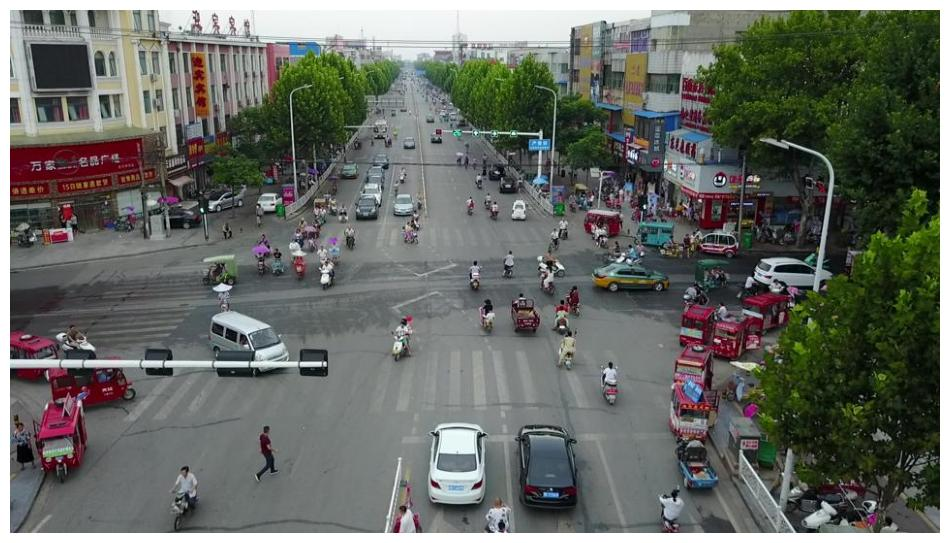

In [3]:
# Use JPEG format for inline visualizations
%config InlineBackend.figure_format = "jpeg"


# Validate and download image safely
def safe_url_download(url: str, save_path: str) -> None:
    """Safely downloads a file from a URL, ensuring the scheme is 'http' or 'https'.

    Args:
        url (str): The URL to download the file from.
        save_path (str): The local path to save the downloaded file.

    Raises:
        ValueError: If the URL scheme is not 'http' or 'https'.
        requests.exceptions.RequestException: For errors during the download.
    """
    # Parse and validate URL scheme
    parsed_url = urlparse(url)
    if parsed_url.scheme not in ("http", "https"):
        raise ValueError(f"Invalid URL scheme '{parsed_url.scheme}'. Only 'http' and 'https' are allowed.")

    # Download the file using requests
    try:
        response = requests.get(url, stream=True, timeout=1000)
        response.raise_for_status()  # Raise an error for bad responses (4xx, 5xx)

        # Save the file locally in chunks
        with open(save_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)

        print(f"File downloaded successfully and saved to {save_path}")
    except requests.exceptions.RequestException as e:
        print(f"Failed to download the file: {e}")


data_dir = "./data"
url = "https://data.kitware.com/api/v1/item/623880f14acac99f429fe3ca/download"

os.makedirs(data_dir, exist_ok=True)

img_path = os.path.join(data_dir, "visdrone_img.jpg")
if not os.path.isfile(img_path):
    safe_url_download(url, img_path)
    print(f"Image downloaded and saved to {img_path}")

img = np.asarray(Image.open(img_path))

plt.figure(figsize=(12, 12))
plt.axis("off")
_ = plt.imshow(img)

We'll also define a function to display detections:

In [4]:
def show_dets(  # noqa:C901
    ax: Axes,
    dets: Iterable[tuple[AxisAlignedBoundingBox, dict[Hashable, float]]],
    thresh: float = 0.5,
    show_labels: bool = False,
    show_ids: bool = False,
) -> None:
    """Displays detection bounding boxes on a given axis with optional class labels and IDs.

    Args:
        ax (Axes): The Matplotlib axis on which to plot the detections.
        dets (List[Tuple[Any, Dict[str, float]]]): A list of detections where each detection is a tuple:
            - The first element is the bounding box object (with `min_vertex` and `max_vertex` attributes).
            - The second element is a dictionary mapping class names to confidence scores.
        thresh (float, optional): Confidence threshold for displaying detections. Defaults to 0.5.
        show_labels (bool, optional): Whether to display class labels and confidence scores. Defaults to False.
        show_ids (bool, optional): Whether to display detection IDs. Defaults to False.

    Returns:
        None
    """
    for i, det in enumerate(dets):
        score_dict = det[1]
        cls_name = max(score_dict, key=lambda k: score_dict[k])
        conf = score_dict[cls_name]

        if conf >= thresh:
            bbox = det[0]
            x_1, y_1 = bbox.min_vertex
            x_2, y_2 = bbox.max_vertex
            ax.add_patch(Rectangle((x_1, y_1), x_2 - x_1, y_2 - y_1, linewidth=1, edgecolor="r", facecolor="none"))

            labels = []
            if show_labels:
                labels.append(f"{cls_name} {conf:.2f}")
            if show_ids:
                labels.append(f"({i})")
            if labels:
                label = " ".join(labels)
                ax.text(x_1, y_1 - 2, label, color="b", fontsize=8)

## Instantiate Protocol-Based Detector <a name="instantiate-protocol-based-detector"></a>

First, we need a detector that uses the object detection protocol. Here we'll be be wrapping a model from Hugging Face, but this could be **any** model that conforms to the object detection protocol!

In [ ]:
@dataclass
class DetectionTarget:
    """Represents the detection results for an object detection task.

    Attributes:
        boxes (torch.Tensor): Tensor of bounding boxes with shape `(num_boxes, 4)`.
            Each row represents a box in the format `[x_min, y_min, x_max, y_max]`.
        labels (torch.Tensor): Tensor of class labels for the detected objects with shape `(num_boxes,)`.
        scores (torch.Tensor): Tensor of confidence scores for the detected objects with shape `(num_boxes,)`.
    """

    boxes: torch.Tensor
    labels: torch.Tensor
    scores: torch.Tensor


class HuggingFaceDetector:
    """A wrapper for a Hugging Face object detection model, allowing easy inference and post-processing.

    Attributes:
        image_processor (AutoImageProcessor): The processor for preparing input images for the model.
        model (AutoModelForObjectDetection): The pre-trained Hugging Face object detection model.
        threshold (float): Confidence score threshold for filtering detection results.
        device (str): The device to run the model on (e.g., "cpu" or "cuda").
    """

    def __init__(self, model_name: str, threshold: float, device: str) -> None:
        """Initializes the HuggingFaceDetector with a pre-trained model, a confidence threshold, and a device.

        Args:
            model_name (str): The name of the pre-trained model from Hugging Face.
            threshold (float): Confidence threshold for filtering detection results.
            device (str): The device to use for running the model (e.g., "cpu" or "cuda").
        """
        self.image_processor = AutoImageProcessor.from_pretrained(model_name)
        self.model = AutoModelForObjectDetection.from_pretrained(model_name)
        self.threshold = threshold
        self.device = device

        self.model.eval()
        self.model.to(device)

        self.metadata = ModelMetadata(
            id=model_name,
            index2label=self.model.config.id2label,
        )

    def id2label(self) -> dict[int, Hashable]:
        """Retrieves the mapping of class IDs to labels from the model's configuration.

        Returns:
            Dict[int, Hashable]: A dictionary mapping class IDs to human-readable labels.
        """
        return self.model.config.id2label

    def __call__(self, batch: Sequence[od.InputType]) -> Sequence[od.TargetType]:
        """Performs object detection on a batch of images and returns the detection results.

        Args:
            batch (Sequence[od.InputType]): A batch of input images as with shape
                                            `(batch_size, channels, height, width)`.

        Raises:
            ValueError: If the input batch does not have 4 dimensions.

        Returns:
            Sequence[od.TargetType]: A sequence of `DetectionTarget` objects containing detection results for each
                                     image.
        """
        # tensor bridging
        model_input = torch.as_tensor(batch)
        if model_input.ndim != 4:
            raise ValueError("Wrong number of input dimensions")

        # save original image sizes for resizing boxes
        target_sizes = [get_image_size(img)[::-1] for img in model_input]

        # preprocess
        hf_inputs = self.image_processor(model_input, return_tensors="pt")

        # put on device
        hf_inputs = hf_inputs.to(self.device)

        # get predictions
        with torch.no_grad():
            hf_predictions = self.model(**hf_inputs)
        hf_results = self.image_processor.post_process_object_detection(
            hf_predictions,
            threshold=self.threshold,
            target_sizes=target_sizes,
        )

        predictions: Sequence[od.TargetType] = list()
        for result in hf_results:
            predictions.append(
                DetectionTarget(
                    result["boxes"].detach().cpu(),
                    result["labels"].detach().cpu(),
                    result["scores"].detach().cpu(),
                ),
            )

        return predictions


model_name = "facebook/detr-resnet-50"
maite_detector: od.Model = HuggingFaceDetector(
    model_name=model_name,
    threshold=0.5,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model)

## Transform Protocol-Based Detector <a name="transform-protocol-based-detector"></a>

Now that we have our MAITE protocol-based detector, we can wrap it so that it can be used directly with `xaitk-saliency`.

In [ ]:
detector = MAITEDetector(detector=maite_detector, ids=sorted(maite_detector.id2label().keys()), img_batch_size=5)

## Use the Detector as "Normal" <a name="use-detector-as-normal"></a>

Now the detector can be used just like it is a regular `DetectImageObjects` implementation with `xaitk-saliency`.

### Get Detections <a name="get-detections"></a>

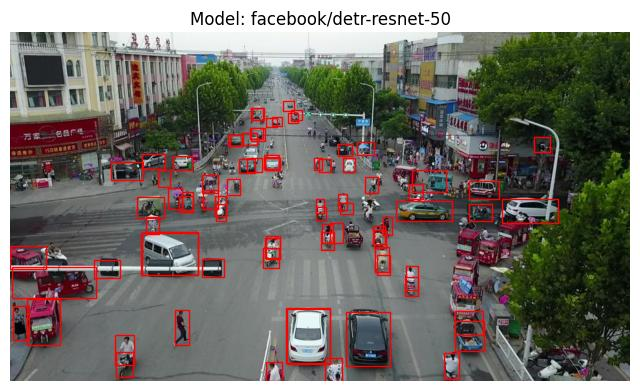

In [7]:
dets = list(detector([img]))[0]

# Display detections
fig, axs = plt.subplots(figsize=(8, 8))
axs.set_title(f"Model: {model_name}")  # type: ignore
axs.imshow(img)  # type: ignore
axs.axis("off")  # type: ignore
show_dets(axs, dets, thresh=0.4)

### Generate Saliency Maps <a name="generate-saliency-maps"></a>

For the sake of this example, we have pre-selected four reference detections from the predictions made by the model to compute saliency maps. These are displayed below.

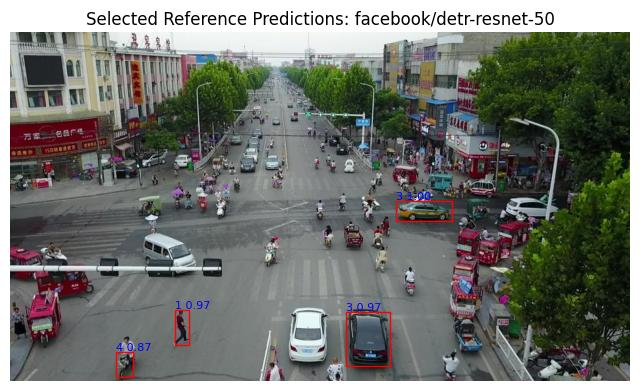

In [8]:
# indices of reference detections
centernet_idxs = [2, 74, 23, 73]
centernet_ref_dets = [list(dets)[idx] for idx in centernet_idxs]

fig, axs = plt.subplots(figsize=(8, 8))
axs.set_title(f"Selected Reference Predictions: {model_name}")  # type: ignore
axs.imshow(img)  # type: ignore
axs.axis("off")  # type: ignore
show_dets(axs, centernet_ref_dets, thresh=0.4, show_labels=True)

#### Prepare Inputs <a name="prepare-inputs"></a>

The `GenerateObjectDetectorBlackboxSaliency` interface requires our reference detections to be split into separate bounding boxes and scores inputs, both as numpy arrays.

In [ ]:
def dets_to_mats(dets: list[tuple[AxisAlignedBoundingBox, dict[Hashable, float]]]) -> tuple[np.ndarray, np.ndarray]:
    """Converts detection results into matrices of bounding boxes and class scores.

    Args:
        dets (List[Tuple[Any, Dict[str, float]]]): A list of detections, where each detection is a tuple containing:
            - A bounding box object (with `min_vertex` and `max_vertex` attributes).
            - A dictionary mapping class labels to their associated scores.

    Returns:
        Tuple[np.ndarray, np.ndarray]:
            - bboxes (np.ndarray): A NumPy array of shape `(n, 4)` where `n` is the number of detections.
                Each row represents a bounding box in the format `[x_min, y_min, x_max, y_max]`.
            - scores (np.ndarray): A NumPy array of shape `(n, c)` where `c` is the number of class labels.
                Each row represents the scores for all classes for the corresponding bounding box.
    """
    labels = sorted(maite_detector.id2label().keys())  # type: ignore

    bboxes = np.empty((0, 4))
    scores = np.empty((0, len(labels)))
    for det in dets:
        bbox = det[0]

        bboxes = np.vstack(
            (
                bboxes,
                [
                    *bbox.min_vertex,
                    *bbox.max_vertex,
                ],
            ),
        )

        score_dict = det[1]
        score_array = [score_dict[label] for label in labels]

        scores = np.vstack(
            (
                scores,
                score_array,
            ),
        )

    return bboxes, scores


centernet_bboxes, centernet_scores = dets_to_mats(centernet_ref_dets)

#### Saliency Generation <a name="saliency-generation"></a>

We'll use the `RandomGridStack` implementation to generate our saliency maps.

In [10]:
sal_generator = RandomGridStack(
    n=150,  # number of masks
    s=(7, 7),  # occlusion grid cell size in pixels
    p1=0.7,  # probability of not occluding cell
    threads=8,  # execution threads
    seed=42,  # seed for replicable results
)

# gray average of VisDrone
fill = [95, 96, 93]
sal_generator.fill = fill

In [11]:
print("Generating CenterNet saliency maps...")
start = time.time()
centernet_sal_maps = sal_generator(img, centernet_bboxes, centernet_scores, detector)
end = time.time()
print(f"Done in {end - start:.2f}s")

Generating CenterNet saliency maps...
Done in 36.72s


#### Display Saliency Maps <a name="display-saliency-maps"></a>

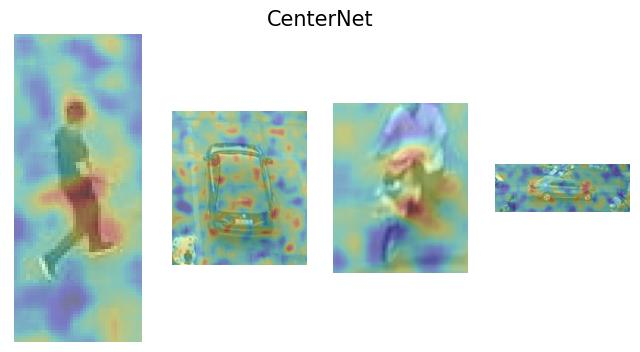

In [12]:
gray_img = np.asarray(Image.fromarray(img).convert("L"))
pad_perc = 0.4

n = len(centernet_sal_maps)

fig, axs = plt.subplots(1, n, figsize=(8, 4))

for i, ax in enumerate(axs):
    try:
        sal_map = centernet_sal_maps[i]
    except IndexError:
        ax.axis("off")
        continue

    x_1, y_1, x_2, y_2 = centernet_bboxes[i]
    pad_x = pad_perc * (x_2 - x_1)
    pad_y = pad_perc * (y_2 - y_1)
    x_1 = max(int(x_1 - pad_x), 0)
    y_1 = max(int(y_1 - pad_y), 0)
    x_2 = int(x_2 + pad_x)
    y_2 = int(y_2 + pad_y)

    img_crop = gray_img[y_1 : (y_2 + 1), x_1 : (x_2 + 1)]
    sal_crop = sal_map[y_1 : (y_2 + 1), x_1 : (x_2 + 1)]

    ax.imshow(img_crop, alpha=0.7, cmap="gray")
    ax.imshow(sal_crop, alpha=0.3, cmap="jet")
    ax.axis("off")

axs = fig.subplots()
axs.set_title("CenterNet", fontsize=15)  # type: ignore
_ = axs.axis("off")  # type: ignore